# Fairness post-processing (Hardt, Price, Srebro 2016) sur `ausprivauto0405` (CASdatasets)

Ce notebook applique **Equal Opportunity** et **Equalized Odds** via post-traitement (sans ré-entraîner les modèles) et compare :
- modèles de base (scores/probabilités),
- post-traitement **à partir des scores** (méthode la plus informative),
- post-traitement **à partir des prédictions binaires** (méthode plus “grossière”).

---

## Notations (papier Hardt et al.)
- **Y** : vraie étiquette (ici `ClaimOcc` ∈ {0,1})
- **A** : attribut sensible / groupe (ici `Gender`)
- **R** : score continu (souvent une probabilité) produit par un modèle
- **Ŷ** : prédiction binaire de base (après seuillage de R)
- **Ỹ** : prédicteur *corrigé* (post-traité) construit à partir de (R, A) ou (Ŷ, A)

---

## Point crucial (cas imbalanced)
Dans ce dataset, `ClaimOcc=1` est rare (~6–7%).  
Si on minimisait simplement l’erreur 0/1 (coût FP = coût FN), la solution “juste et optimale” peut devenir **triviale** : prédire *toujours 0* (aucun sinistre).  
C’est “fair” au sens EO/EOpp, mais inutile opérationnellement.

On montrera donc **deux réglages de coût** :
- `cost_fp=1, cost_fn=1` (erreur standard) → risque de solution triviale
- `cost_fp=1, cost_fn=10` (manquer un sinistre coûte plus cher) → décisions plus actives

Et on montrera aussi une politique de décision réaliste : **sélectionner le top 10% des risques** (capacitaire).


In [ ]:
import os, tarfile, tempfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Import du post-traitement
import sys, pathlib
sys.path.append(str(pathlib.Path().resolve()))
from fairness_postprocess_hardt import ScorePostProcessor, BinaryPostProcessor, fairness_report


c:\Users\chris\Downloads\fairness_postprocess_hardt.py:105: SyntaxWarning: invalid escape sequence '\h'
  Post-process a real-valued score R into a fair binary decision \hat{Y}
c:\Users\chris\Downloads\fairness_postprocess_hardt.py:234: SyntaxWarning: invalid escape sequence '\h'
  """Return P(\hat{Y}=1 | score, group) implied by randomized thresholds."""
c:\Users\chris\Downloads\fairness_postprocess_hardt.py:281: SyntaxWarning: invalid escape sequence '\h'
  Post-process an existing binary predictor Y_pred into a fair predictor \hat{Y}


## 1) Chargement du dataset `ausprivauto0405`

Source : package R `CASdatasets` (dutangc).  
Le dataset contient des informations véhicule/conducteur et la variable `ClaimOcc` (occurrence d’un sinistre).

In [2]:
url = "https://dutangc.perso.math.cnrs.fr/RRepository/pub/src/contrib/CASdatasets_1.2-0.tar.gz"

# Le tar.gz est volumineux. Si tu l'as déjà téléchargé, mets-le à côté du notebook
# et renseigne `local_tgz_path`. Sinon, il sera téléchargé.
local_tgz_path = None  # ex: "CASdatasets_1.2-0.tar.gz"

import pyreadr

with tempfile.TemporaryDirectory() as td:
    if local_tgz_path is not None and os.path.exists(local_tgz_path):
        tgz_path = local_tgz_path
    else:
        tgz_path = os.path.join(td, "CASdatasets.tar.gz")
        urllib.request.urlretrieve(url, tgz_path)

    with tarfile.open(tgz_path, "r:gz") as tar:
        member = next(m for m in tar.getmembers() if m.name.endswith("data/ausprivauto0405.rda"))
        tar.extract(member, path=td)

    rda_path = os.path.join(td, member.name)
    obj = pyreadr.read_r(rda_path)
    df = obj["ausprivauto0405"]

df.head()


C:\Users\chris\AppData\Local\Temp\ipykernel_170436\1041565474.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=td)


,Exposure,VehValue,VehAge,VehBody,Gender,DrivAge,ClaimOcc,ClaimNb,ClaimAmount
0,0.303901,1.06,old cars,Hatchback,Female,young people,0,0,0.0
1,0.648871,1.03,young cars,Hatchback,Female,older work. people,0,0,0.0
2,0.569473,3.26,young cars,Utility,Female,young people,0,0,0.0
3,0.317591,4.14,young cars,Station wagon,Female,young people,0,0,0.0
4,0.648871,0.72,oldest cars,Hatchback,Female,young people,0,0,0.0


## 2) EDA minimal : taille, variables, base rates

On se concentre sur :
- Y = `ClaimOcc` (0/1)
- A = `Gender` (Female/Male)


In [13]:
# Convertir les catégorielles en str pour sklearn
df2 = df.copy()
for c in ["VehAge","VehBody","Gender","DrivAge"]:
    df2[c] = df2[c].astype(str)

y = df2["ClaimOcc"].astype(int).to_numpy()
A = df2["Gender"].to_numpy()

print("Shape:", df2.shape)
print("\nPrévalence globale P(Y=1):", y.mean())
print("\nPrévalence par groupe:")
display(df2.groupby("Gender")["ClaimOcc"].mean().rename("P(Y=1|A)"))

display(df2.dtypes)


Shape: (67856, 9)

Prévalence globale P(Y=1): 0.06814430558830464

Prévalence par groupe:


Gender
Female    0.068596
Male      0.067549
Name: P(Y=1|A), dtype: float64

Exposure       float64
VehValue       float64
VehAge          object
VehBody         object
Gender          object
DrivAge         object
ClaimOcc         int32
ClaimNb          int32
ClaimAmount    float64
dtype: object

## 3) Split : train / calibration / test


- Train : entraîner le modèle de base (R = score)
- Calibration : apprendre la correction (EO/EOpp)
- Test : comparer baseline vs corrections


In [14]:
# Features : on exclut Gender des features (pour la baseline)
# (on l'utilise quand même pour la correction et l'évaluation)
feature_cols = ["Exposure","VehValue","VehAge","VehBody","DrivAge"]
X = df2[feature_cols]

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.30, random_state=42, stratify=y
)
X_tr, X_cal, y_tr, y_cal, A_tr, A_cal = train_test_split(
    X_train, y_train, A_train, test_size=0.25, random_state=0, stratify=y_train
)

print("Train:", X_tr.shape, " Calibration:", X_cal.shape, " Test:", X_test.shape)


Train: (35624, 5)  Calibration: (11875, 5)  Test: (20357, 5)


## 4) Modèles de base (scores R)

On entraîne 2 modèles simples :
- Régression logistique (linéaire)
- Gradient Boosting (non-linéaire)

On produit un **score** `R = P(Y=1|X)`.

**Remarque** : avec une prévalence ~6–7%, un seuil 0.5 produit presque toujours Ŷ=0.  
Pour une comparaison réaliste, on utilisera aussi une politique **top 10%** (décider positif pour les 10% plus hauts risques).


In [5]:
num_cols = ["Exposure","VehValue"]
cat_cols = ["VehAge","VehBody","DrivAge"]

pre = ColumnTransformer([
    ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

pipelines = {
    "LogReg": Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=500))]),
    "GradBoost": Pipeline([("pre", pre), ("clf", GradientBoostingClassifier(random_state=42))]),
}

base_models = {}
for name, pipe in pipelines.items():
    pipe.fit(X_tr, y_tr)
    base_models[name] = pipe

# Scores sur calibration & test
scores_cal = {name: mdl.predict_proba(X_cal)[:,1] for name, mdl in base_models.items()}
scores_test = {name: mdl.predict_proba(X_test)[:,1] for name, mdl in base_models.items()}

# Metrics "scores" (AUC / logloss)
rows=[]
for name in base_models:
    rows.append({
        "Model": name,
        "AUC(test)": roc_auc_score(y_test, scores_test[name]),
        "LogLoss(test)": log_loss(y_test, scores_test[name], labels=[0,1]),
        "Mean score": float(scores_test[name].mean()),
        "Max score": float(scores_test[name].max()),
    })
display(pd.DataFrame(rows))


,Model,AUC(test),LogLoss(test),Mean score,Max score
0,LogReg,0.664884,0.238320,0.068246,0.248379
1,GradBoost,0.663840,0.237988,0.068396,0.443177


## 5) Déterminer si la fairness est violée

### (A) Par définition (comptage → probabilités conditionnelles)
À partir des TP/FP/TN/FN *par groupe*, on estime :
- TPR = P(Ŷ=1 | Y=1, A=a)
- FPR = P(Ŷ=1 | Y=0, A=a)

EOpp est violée si les **TPR** diffèrent.
EO est violée si **TPR** *ou* **FPR** diffèrent.

### (B) Via ROC par groupe
En balayant le seuil sur R, on observe les couples (FPR,TPR) par groupe.  
EO correspond à pouvoir aligner les groupes sur le même point ROC (souvent via randomisation).


In [6]:
def threshold_top_k(proba, rate=0.10):
    # Seuil tel que ~rate des scores dépassent le seuil (top-k policy)
    return float(np.quantile(proba, 1-rate))

# Seuil top10% calculé sur la calibration (pas sur le test)
policy_rate = 0.10
thr_cal = {name: threshold_top_k(scores_cal[name], policy_rate) for name in base_models}

# Prédictions Ŷ sur test sous la politique top10%
pred_test = {name: (scores_test[name] >= thr_cal[name]).astype(int) for name in base_models}

print("Seuils (calibration) pour top10% :")
display(pd.DataFrame({"Model": list(thr_cal.keys()), "threshold": list(thr_cal.values())}))

print("\nFairness report baseline (Ŷ) sur test :")
for name in base_models:
    print(f"\n=== {name} ===")
    display(fairness_report(y_test, pred_test[name], A_test))


Seuils (calibration) pour top10% :


,Model,threshold
0,LogReg,0.122055
1,GradBoost,0.115928



Fairness report baseline (Ŷ) sur test :

=== LogReg ===


,group,n,TP,FP,TN,FN,TPR,FPR,SelectionRate,Accuracy,TPR_gap(max-min),FPR_gap(max-min),SelectionRate_gap(max-min),Accuracy_gap(max-min)
0,Female,11482,138,1003,9715,626,0.180628,0.093581,0.099373,0.858126,0.000853,0.004754,0.004162,0.001705
1,Male,8875,112,733,7519,511,0.179775,0.088827,0.095211,0.859831,0.000853,0.004754,0.004162,0.001705



=== GradBoost ===


,group,n,TP,FP,TN,FN,TPR,FPR,SelectionRate,Accuracy,TPR_gap(max-min),FPR_gap(max-min),SelectionRate_gap(max-min),Accuracy_gap(max-min)
0,Female,11482,130,982,9736,634,0.170157,0.091622,0.096847,0.859258,0.0353,0.014777,0.016505,0.013962
1,Male,8875,128,878,7374,495,0.205457,0.106398,0.113352,0.845296,0.0353,0.014777,0.016505,0.013962


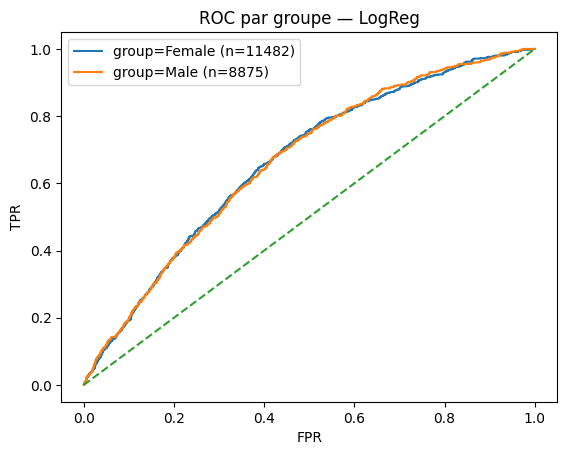

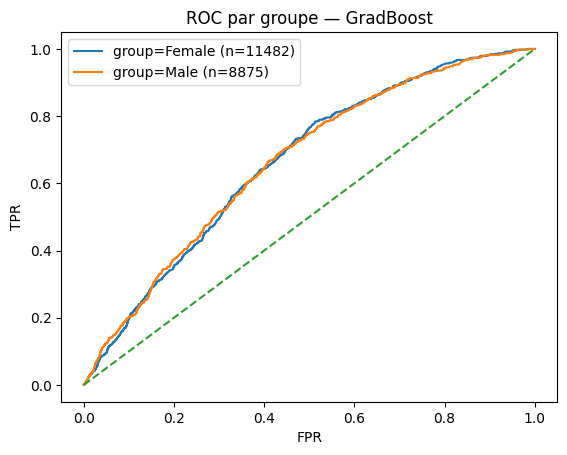

In [7]:
from sklearn.metrics import roc_curve

def plot_group_roc(y_true, score, group, title):
    plt.figure()
    for g in np.unique(group):
        m = (group == g)
        fpr, tpr, _ = roc_curve(y_true[m], score[m])
        plt.plot(fpr, tpr, label=f"group={g} (n={m.sum()})")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.show()

for name in base_models:
    plot_group_roc(y_test, scores_test[name], A_test, title=f"ROC par groupe — {name}")


## 6) Post-traitement Hardt et al. : Score vs Binaire

### 6.1 Post-traitement à partir du score R (recommandé)
On apprend une règle (souvent randomisée) Ỹ = f(R, A) qui :
- minimise une perte (coût FP/FN),
- sous contrainte EO ou EOpp.

### 6.2 Post-traitement à partir de Ŷ (binaire)
Si on ne garde que Ŷ (0/1), on ne peut plus “choisir un seuil”.
À la place, on apprend des probabilités de flip par groupe :
- p(A=a, Ŷ=0) = P(Ỹ=1 | A=a, Ŷ=0)
- p(A=a, Ŷ=1) = P(Ỹ=1 | A=a, Ŷ=1)

C’est moins flexible que la version score, car on a perdu de l’information.


In [8]:
def fairness_report_expected(y_true, p_pred, a):
    """Rapport fairness en *espérance* pour des prédictions randomisées.
    p_pred = P(Ỹ=1 | ...) pour chaque observation.
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)
    a = np.asarray(a)

    rows=[]
    for g in pd.unique(a):
        m = (a==g)
        yt = y_true[m]
        pp = p_pred[m]

        tp = float(pp[yt==1].sum())
        fn = float((1-pp[yt==1]).sum())
        fp = float(pp[yt==0].sum())
        tn = float((1-pp[yt==0]).sum())

        pos = tp+fn
        neg = tn+fp

        rows.append({
            "group": g, "n": int(m.sum()),
            "TP(exp)": tp, "FP(exp)": fp, "TN(exp)": tn, "FN(exp)": fn,
            "TPR(exp)": tp/pos if pos else np.nan,
            "FPR(exp)": fp/neg if neg else np.nan,
            "SelectionRate(exp)": float(pp.mean()),
            "Accuracy(exp)": (tp+tn)/(pos+neg),
        })

    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    out["TPR_gap"] = float(out["TPR(exp)"].max() - out["TPR(exp)"].min())
    out["FPR_gap"] = float(out["FPR(exp)"].max() - out["FPR(exp)"].min())
    out["SelectionRate_gap"] = float(out["SelectionRate(exp)"].max() - out["SelectionRate(exp)"].min())
    return out

def overall_expected_metrics(y_true, p_pred):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p_pred).astype(float)
    tp = float(p[y_true==1].sum())
    fn = float((1-p)[y_true==1].sum())
    fp = float(p[y_true==0].sum())
    tn = float((1-p)[y_true==0].sum())
    acc = (tp+tn)/(tp+tn+fp+fn)
    return {"Accuracy(exp)": acc, "SelectionRate(exp)": float(p.mean())}


In [9]:
# Hyperparamètres post-traitement
N_THR = 250  # taille de grille de seuils
COSTS = {
    "cost1":  (1.0, 1.0),   # coût FP, coût FN
    "cost10": (1.0, 10.0),
}
FAIRNESS = {
    "EOpp": "equal_opportunity",
    "EO":   "equalized_odds",
}

score_pp = {}
binary_pp = {}

# 1) Score post-processing : apprend Ỹ = f(R,A)
for model_name in base_models:
    for fair_name, fair_method in FAIRNESS.items():
        for cost_name, (c_fp, c_fn) in COSTS.items():
            pp = ScorePostProcessor(method=fair_method, cost_fp=c_fp, cost_fn=c_fn, n_thresholds=N_THR, random_state=0)
            pp.fit(y_cal, scores_cal[model_name], A_cal)
            score_pp[(model_name, fair_name, cost_name)] = pp

# 2) Binary post-processing : apprend flip probs à partir de Ŷ
for model_name in base_models:
    yhat_cal = (scores_cal[model_name] >= thr_cal[model_name]).astype(int)  # baseline binaire sur calibration
    for fair_name, fair_method in FAIRNESS.items():
        for cost_name, (c_fp, c_fn) in COSTS.items():
            bp = BinaryPostProcessor(method=fair_method, cost_fp=c_fp, cost_fn=c_fn, random_state=0)
            bp.fit(y_cal, yhat_cal, A_cal)
            binary_pp[(model_name, fair_name, cost_name)] = bp

print("OK — post-traitements appris sur la calibration.")


OK — post-traitements appris sur la calibration.


## 7) Évaluation : baseline vs post-traitements

On compare :
- Baseline Ŷ (top10% sur R, seuil appris sur calibration)
- Score post-processing (EO/EOpp, cost1 et cost10)
- Binary post-processing (EO/EOpp, cost1 et cost10)

**Important :** le prédicteur corrigé peut être randomisé → on évalue en **espérance** via `P(Ỹ=1)` (plus stable).


In [10]:
summary_rows = []

# Baseline
for model_name in base_models:
    yhat = pred_test[model_name]
    rep = fairness_report(y_test, yhat, A_test)
    summary_rows.append({
        "Model": model_name,
        "Approach": "Baseline (top10%)",
        "Fairness": "—",
        "Costs": "—",
        "AUC": roc_auc_score(y_test, scores_test[model_name]),
        "Accuracy": accuracy_score(y_test, yhat),
        "SelectionRate": float(yhat.mean()),
        "TPR_gap": float(rep["TPR_gap(max-min)"].iloc[0]),
        "FPR_gap": float(rep["FPR_gap(max-min)"].iloc[0]),
    })

# Score post-processing
for (model_name, fair_name, cost_name), pp in score_pp.items():
    p_fair = pp.predict_proba(scores_test[model_name], A_test)
    rep = fairness_report_expected(y_test, p_fair, A_test)
    ov = overall_expected_metrics(y_test, p_fair)
    summary_rows.append({
        "Model": model_name,
        "Approach": "Score post-processing",
        "Fairness": fair_name,
        "Costs": cost_name,
        "AUC": roc_auc_score(y_test, p_fair),
        "Accuracy": ov["Accuracy(exp)"],
        "SelectionRate": ov["SelectionRate(exp)"],
        "TPR_gap": float(rep["TPR_gap"].iloc[0]),
        "FPR_gap": float(rep["FPR_gap"].iloc[0]),
    })

# Binary post-processing
for (model_name, fair_name, cost_name), bp in binary_pp.items():
    yhat = pred_test[model_name]
    p_fair = bp.predict_proba(yhat, A_test)
    rep = fairness_report_expected(y_test, p_fair, A_test)
    ov = overall_expected_metrics(y_test, p_fair)
    summary_rows.append({
        "Model": model_name,
        "Approach": "Binary post-processing",
        "Fairness": fair_name,
        "Costs": cost_name,
        "AUC": roc_auc_score(y_test, p_fair),
        "Accuracy": ov["Accuracy(exp)"],
        "SelectionRate": ov["SelectionRate(exp)"],
        "TPR_gap": float(rep["TPR_gap"].iloc[0]),
        "FPR_gap": float(rep["FPR_gap"].iloc[0]),
    })

summary = pd.DataFrame(summary_rows).sort_values(["Model","Approach","Fairness","Costs"])
display(summary)


,Model,Approach,Fairness,Costs,AUC,Accuracy,SelectionRate,TPR_gap,FPR_gap
1,GradBoost,Baseline (top10%),—,—,0.663840,0.853171,0.104043,0.035300,0.014777
16,GradBoost,Binary post-processing,EO,cost1,0.500000,0.931866,0.000000,0.000000,0.000000
17,GradBoost,Binary post-processing,EO,cost10,0.546502,0.858300,0.097110,0.005832,0.000100
14,GradBoost,Binary post-processing,EOpp,cost1,0.500000,0.931866,0.000000,0.000000,0.000000
15,GradBoost,Binary post-processing,EOpp,cost10,0.543762,0.858442,0.096973,0.005908,0.000444
8,GradBoost,Score post-processing,EO,cost1,0.500000,0.931866,0.000000,0.000000,0.000000
9,GradBoost,Score post-processing,EO,cost10,0.625937,0.657810,0.349119,0.044158,0.011416
6,GradBoost,Score post-processing,EOpp,cost1,0.500000,0.931866,0.000000,0.000000,0.000000
7,GradBoost,Score post-processing,EOpp,cost10,0.620611,0.665589,0.340287,0.061353,0.031907
0,LogReg,Baseline (top10%),—,—,0.664884,0.858869,0.097559,0.000853,0.004754


## 8) Interprétation (sur ce dataset)

### 8.1 Baseline (top 10%)
- La régression logistique a une disparité **faible** entre genres (TPR_gap/FPR_gap plutôt petits).
- Le Gradient Boosting, avec la même politique top10%, montre des écarts plus visibles (TPR_gap/FPR_gap plus grands).  
  → Cela illustre qu’un modèle plus flexible peut amplifier des différences de distribution entre groupes, même sans utiliser `Gender` comme feature.

### 8.2 Post-traitement `cost1 = (FP=1, FN=1)` : solution triviale
Pour **EOpp** et **EO**, le post-traitement score et binaire ont tendance à produire :
- **SelectionRate ≈ 0**
- **TPR ≈ 0, FPR ≈ 0**

Pourquoi ?  
Parce que la classe positive est rare : prédire toujours 0 maximise l’accuracy et minimise l’erreur 0/1, tout en satisfaisant parfaitement EO/EOpp.

Conclusion : **il faut exprimer l’objectif métier** (coût, contrainte de sélection, etc.) sinon on obtient une fairness “vide”.

### 8.3 Post-traitement `cost10 = (FP=1, FN=10)` : compromis utile
Quand rater un sinistre est plus “cher” :
- Les post-traitements deviennent actifs (TPR et FPR montent).
- Le post-traitement **score** peut augmenter fortement le taux de sélection (ex: 25–35%), car il choisit le point ROC optimal sous contrainte.
- Le post-traitement **binaire** est plus conservateur : il part d’une baseline top10% et ajuste par flips, donc reste proche en taux de sélection.

Lecture pratique :
- **Score post-processing** : meilleure flexibilité (mais peut changer fortement la politique de décision).
- **Binary post-processing** : plus “proche” de la baseline, mais moins puissant.

### 8.4 Fairness sur calibration vs test
Les contraintes EO/EOpp sont satisfaites **exactement (en espérance)** sur la calibration (là où on a appris le post-traitement).  
Sur le test, les gaps peuvent réapparaître légèrement à cause du *shift* (différences d’échantillonnage).

Bonne pratique : conserver une calibration représentative et surveiller ces métriques en production.


## 8bis) Lecture automatique : “meilleurs” compromis (indicatif)

Le bloc ci-dessous identifie, à partir du tableau `summary`, des configurations :
- **très fair** : gaps faibles (TPR_gap et FPR_gap)
- **et** avec bonne accuracy / AUC.


In [ ]:
# Analyse simple des compromis à partir de `summary`
# (exécuter après avoir obtenu le DataFrame summary)

tmp = summary.copy()

# Normaliser (pour un score global naïf)
# On pénalise les gaps et on valorise l'accuracy; on met aussi une pénalité si SelectionRate est trop extrême.
tmp["gap_score"] = tmp["TPR_gap"].fillna(0) + tmp["FPR_gap"].fillna(0)
tmp["sel_penalty"] = (tmp["SelectionRate"] - 0.10).abs()  # proche de la baseline top10%
tmp["overall_score"] = tmp["gap_score"] + 0.5*tmp["sel_penalty"] - 0.2*tmp["Accuracy"]

# Top 10 par modèle
for model in tmp["Model"].unique():
    print(f"\n===== Best compromises (heuristique) — {model} =====")
    display(
        tmp[tmp["Model"]==model]
        .sort_values("overall_score")
        .head(10)[["Model","Approach","Fairness","Costs","Accuracy","AUC","SelectionRate","TPR_gap","FPR_gap","overall_score"]]
    )

print("\nNote: les lignes 'cost1' peuvent paraître excellentes car elles prédisent presque toujours 0.")



===== Best compromises (heuristique) — GradBoost =====


,Model,Approach,Fairness,Costs,Accuracy,AUC,SelectionRate,TPR_gap,FPR_gap,overall_score
17,GradBoost,Binary post-processing,EO,cost10,0.858300,0.546502,0.097110,0.005832,0.000100,-0.164283
15,GradBoost,Binary post-processing,EOpp,cost10,0.858442,0.543762,0.096973,0.005908,0.000444,-0.163823
16,GradBoost,Binary post-processing,EO,cost1,0.931866,0.500000,0.000000,0.000000,0.000000,-0.136373
14,GradBoost,Binary post-processing,EOpp,cost1,0.931866,0.500000,0.000000,0.000000,0.000000,-0.136373
8,GradBoost,Score post-processing,EO,cost1,0.931866,0.500000,0.000000,0.000000,0.000000,-0.136373
6,GradBoost,Score post-processing,EOpp,cost1,0.931866,0.500000,0.000000,0.000000,0.000000,-0.136373
1,GradBoost,Baseline (top10%),—,—,0.853171,0.663840,0.104043,0.035300,0.014777,-0.118535
9,GradBoost,Score post-processing,EO,cost10,0.657810,0.625937,0.349119,0.044158,0.011416,0.048571
7,GradBoost,Score post-processing,EOpp,cost10,0.665589,0.620611,0.340287,0.061353,0.031907,0.080285



===== Best compromises (heuristique) — LogReg =====


,Model,Approach,Fairness,Costs,Accuracy,AUC,SelectionRate,TPR_gap,FPR_gap,overall_score
0,LogReg,Baseline (top10%),—,—,0.858869,0.664884,0.097559,0.000853,0.004754,-0.164946
13,LogReg,Binary post-processing,EO,cost10,0.857178,0.549046,0.098981,0.005243,0.000913,-0.164771
11,LogReg,Binary post-processing,EOpp,cost10,0.859666,0.544154,0.096474,0.005549,0.007074,-0.157548
4,LogReg,Score post-processing,EO,cost1,0.931768,0.499947,0.000098,0.000000,0.000028,-0.136375
2,LogReg,Score post-processing,EOpp,cost1,0.931768,0.499947,0.000098,0.000000,0.000028,-0.136375
12,LogReg,Binary post-processing,EO,cost1,0.931866,0.500000,0.000000,0.000000,0.000000,-0.136373
10,LogReg,Binary post-processing,EOpp,cost1,0.931866,0.500000,0.000000,0.000000,0.000000,-0.136373
5,LogReg,Score post-processing,EO,cost10,0.715854,0.615352,0.280377,0.023702,0.011872,-0.017409
3,LogReg,Score post-processing,EOpp,cost10,0.718360,0.605295,0.277384,0.031653,0.018655,-0.004672



Note: les lignes 'cost1' peuvent paraître excellentes car elles prédisent presque toujours 0 (accuracy élevée) — à interpréter avec prudence.


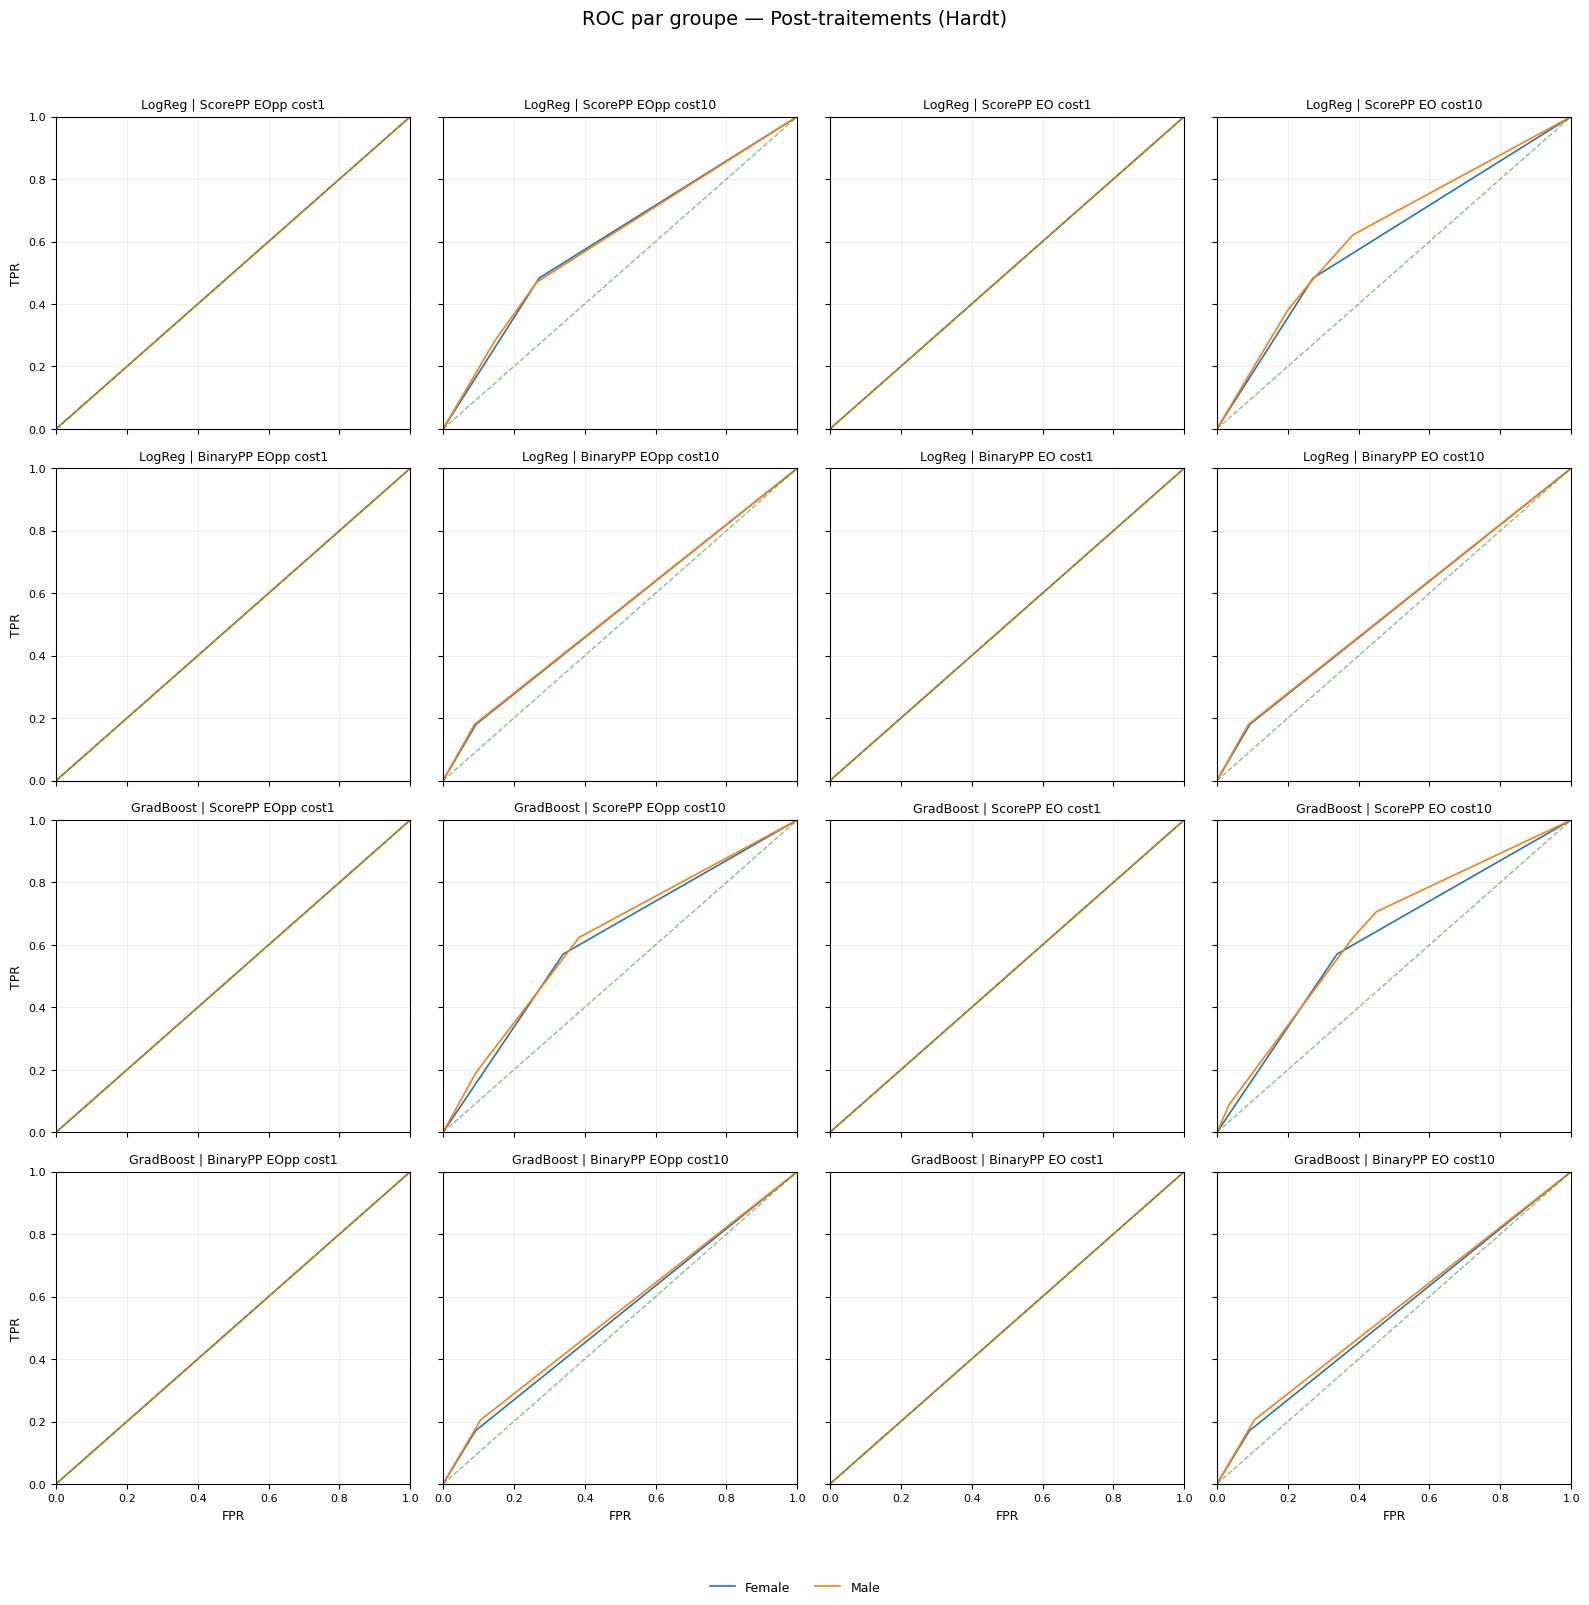

In [16]:
def plot_group_roc_ax(y_true, score, group, ax, title=""):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    group = np.asarray(group)

    groups = list(np.unique(group))
    for g in groups:
        m = (group == g)

        # Si dans un groupe il n'y a qu'une seule classe, la ROC n'est pas définie
        if m.sum() == 0 or len(np.unique(y_true[m])) < 2:
            ax.text(0.5, 0.2, f"ROC indéfinie\n(g={g})", ha="center", va="center", fontsize=7)
            continue

        fpr, tpr, _ = roc_curve(y_true[m], score[m])
        ax.plot(fpr, tpr, label=str(g), linewidth=1.2)

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.0, alpha=0.6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=9)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=8)

# --- Construire la liste des 16 configs (2 modèles × 2 approches × 2 fairness × 2 coûts)
order_models = list(base_models.keys())           # ex: ["LogReg", "GradBoost"]
order_fair = ["EOpp", "EO"]
order_cost = ["cost1", "cost10"]

plots = []
for model_name in order_models:
    # Score post-processing
    for fair_name in order_fair:
        for cost_name in order_cost:
            pp = score_pp[(model_name, fair_name, cost_name)]
            p_fair = pp.predict_proba(scores_test[model_name], A_test)
            plots.append((
                f"{model_name} | ScorePP {fair_name} {cost_name}",
                p_fair
            ))
    # Binary post-processing
    for fair_name in order_fair:
        for cost_name in order_cost:
            bp = binary_pp[(model_name, fair_name, cost_name)]
            p_fair = bp.predict_proba(pred_test[model_name], A_test)
            plots.append((
                f"{model_name} | BinaryPP {fair_name} {cost_name}",
                p_fair
            ))

# --- Grille 4x4
fig, axs = plt.subplots(4, 4, figsize=(16, 16), sharex=True, sharey=True)
axs = axs.ravel()

for i, (title, p_fair) in enumerate(plots):
    plot_group_roc_ax(y_test, p_fair, A_test, axs[i], title=title)

# Axes labels seulement sur la bordure pour alléger
for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")
for ax in axs[12:]:
    ax.set_xlabel("FPR", fontsize=9)
for ax in axs[0::4]:
    ax.set_ylabel("TPR", fontsize=9)

# Légende globale (une seule fois)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False, fontsize=9)

fig.suptitle("ROC par groupe — Post-traitements (Hardt)", fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

On observe un contraste net entre cost1 et cost10. Avec cost1, plusieurs configurations donnent une ROC sur la diagonale (AUC ≈ 0.5) : c’est typique d’une solution « quasi toujours 0 » qui satisfait mécaniquement EO/EOpp mais perd tout pouvoir de classement.

Avec cost10, les courbes repassent au-dessus de la diagonale : le post-traitement devient actif (on pénalise fortement les FN), donc on récupère du signal mais la capacité de ranking reste plus faible que le score de base, car la transformation (dépendance à 𝐴 + randomisation/mélange de seuils) vise surtout à ajuster TPR/FPR plutôt qu’à conserver un classement fin.

Enfin, les courbes Female vs Male sont souvent très proches en cost10, ce qui reflète la réduction des différences de comportement entre groupes. 

**À noter** : pour le binary post-processing, la ROC est souvent plus linéaire car la sortie prend peu de valeurs (on part d’une décision binaire et on applique des probabilités de flip), donc le pouvoir de tri est mécaniquement limité.

## 9) Bonus : comparer un modèle qui *utilise* `Gender` comme feature

In [ ]:
# Utilisons Gender comme feature
feature_cols_g = ["Exposure","VehValue","VehAge","VehBody","DrivAge","Gender"]
Xg = df2[feature_cols_g]

Xg_train, Xg_test, yg_train, yg_test, Ag_train, Ag_test = train_test_split(
    Xg, y, A, test_size=0.30, random_state=42, stratify=y
)
Xg_tr, Xg_cal, yg_tr, yg_cal, Ag_tr, Ag_cal = train_test_split(
    Xg_train, yg_train, Ag_train, test_size=0.25, random_state=0, stratify=yg_train
)

num_cols_g = ["Exposure","VehValue"]
cat_cols_g = ["VehAge","VehBody","DrivAge","Gender"]

pre_g = ColumnTransformer([
    ("num", Pipeline([("scaler", StandardScaler())]), num_cols_g),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_g),
])

mdl_g = Pipeline([("pre", pre_g), ("clf", LogisticRegression(max_iter=500))])
mdl_g.fit(Xg_tr, yg_tr)

s_cal_g = mdl_g.predict_proba(Xg_cal)[:,1]
s_test_g = mdl_g.predict_proba(Xg_test)[:,1]

thr_g = float(np.quantile(s_cal_g, 1-0.10))
yhat_g = (s_test_g >= thr_g).astype(int)

print("AUC:", roc_auc_score(yg_test, s_test_g))
display(fairness_report(yg_test, yhat_g, Ag_test))


AUC: 0.6646766096355989


,group,n,TP,FP,TN,FN,TPR,FPR,SelectionRate,Accuracy,TPR_gap(max-min),FPR_gap(max-min),SelectionRate_gap(max-min),Accuracy_gap(max-min)
0,Female,11482,149,1069,9649,615,0.195026,0.099739,0.106079,0.853336,0.029697,0.016244,0.01684,0.010439
1,Male,8875,103,689,7563,520,0.165329,0.083495,0.089239,0.863775,0.029697,0.016244,0.01684,0.010439
